In [ ]:
#System-specific setup
#Installing Detectron2 in OpenSUSE TW: https://github.com/facebookresearch/detectron2/discussions/5497 

#env var required for my ROCM version
#from os import putenv
#putenv("HSA_OVERRIDE_GFX_VERSION", "11.0.0") #export HSA_OVERRIDE_GFX_VERSION=11.0.0
#!export HSA_OVERRIDE_GFX_VERSION=11.0.0

In [2]:
import torch, detectron2

print("torch: ", torch.__version__)
print("detectron2:", detectron2.__version__)

from detectron2.utils.logger import setup_logger
setup_logger()

import os, cv2, random
import matplotlib.pyplot as plt

# detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

from detectron2.data.datasets import register_coco_instances
register_coco_instances("resistors_train", {}, "dataset/real/train.json", "dataset/real/images")
register_coco_instances("resistors_val", {}, "dataset/real/val.json", "dataset/real/images")

torch:  2.11.0.dev20260113+rocm7.1
detectron2: 0.6


In [3]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("resistors_train",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 300    # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.SOLVER.STEPS = []        # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # only has one class (ballon). (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.

In [ ]:
# TRAIN (If already trained, skip to next section)
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()

In [4]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


[01/02 17:34:55 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


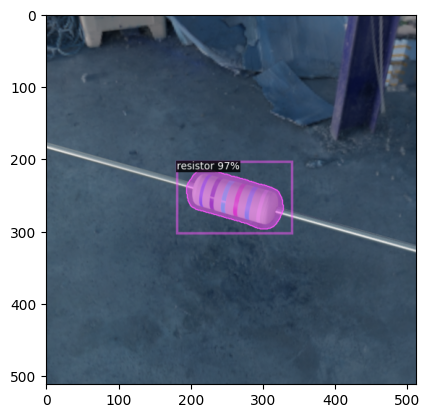

In [40]:
#dataset_dicts = DatasetCatalog.get("resistors_train")
#d = random.sample(dataset_dicts, 1)[0]
#im = cv2.imread(d["file_name"])
im = cv2.imread(f"dataset/synthetic/images/{random.randint(0,2999)}.png")
outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
v = Visualizer(im[:, :, ::-1],
                metadata=MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), 
                scale=1
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.imshow(out.get_image()[:, :, ::-1])